# CART (Classification and Regression Tree) Vs. Linear regression

The purpose of this exercise is to provide an initial sense on how decision Tree compares to a conventional linear regression when the response variable is quantitative.

1.  To begin, construct a regression dataset with known properties:

    ```
    x1 = np.random.normal(size = 300)
    x2 = np.random.normal(size = 300)
    error = 2 * np.random.normal(size = 300)
    y1 = 1 + (2 * x1) + (3 * x2) + error
    ```

    - Apply conventional linear regression using. Then fit a Regression Tree (RT), and print it. 
    - Compare the regression output to the way in which the data were actually generated. 
    - Compare the tree diagram to the way in which the data were actually generated. 
    - Compare how well linear regression and regression Tree fit the data. 
    - What do you conclude about the relative merits of linear regression and RT when the *f(X)* is actually linear and additive ?

2. Now, redefine the two predictors as binary factors and reconstruct the response variable:

    Transform predictors into binary factors
    ```
   x11 = (x1 > 0).astype(int)
   x22 = (x2 > 0).astype(int)
    ```
   Reconstruct the response variable
    ```
   y = 1 + (2 * x11) + (3 * x22) + error
    ```
    - Repeat the comparison. What do you conclude when the *f(X)* is actually a step function and additive ?

3. Under what circumstances is CART likely to perform better than linear regression ? Consider separately the matter of how well the fitted values correspond to the observed values and the implementation of how the predictors are related to the response.


In [29]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
np.random.seed(0)

In [30]:
x1 = np.random.normal(size=300)
x2 = np.random.normal(size=300)
error = 2 * np.random.normal(size=300)
y1 = 1 + 2 * x1 + 3 * x2 + error

X = np.column_stack([x1, x2])

In [31]:
lin_reg = LinearRegression()
lin_reg.fit(X, y1)

LinearRegression()

In [32]:
print("Linear regression coefficients:")
print("intercept:", lin_reg.intercept_)
print("coef:", lin_reg.coef_)

Linear regression coefficients:
intercept: 0.8350097111565937
coef: [1.90602671 3.1716359 ]


In [33]:
y1_pred_lin = lin_reg.predict(X)
mse_lin = mean_squared_error(y1, y1_pred_lin)
print("MSE linear:", mse_lin)

MSE linear: 3.648624524144908


In [34]:
tree = DecisionTreeRegressor(random_state=0, max_depth=3)
tree.fit(X, y1)

DecisionTreeRegressor(max_depth=3, random_state=0)

In [35]:
y1_pred_tree = tree.predict(X)
mse_tree = mean_squared_error(y1, y1_pred_tree)
print("MSE tree:", mse_tree)

MSE tree: 4.43222868602447


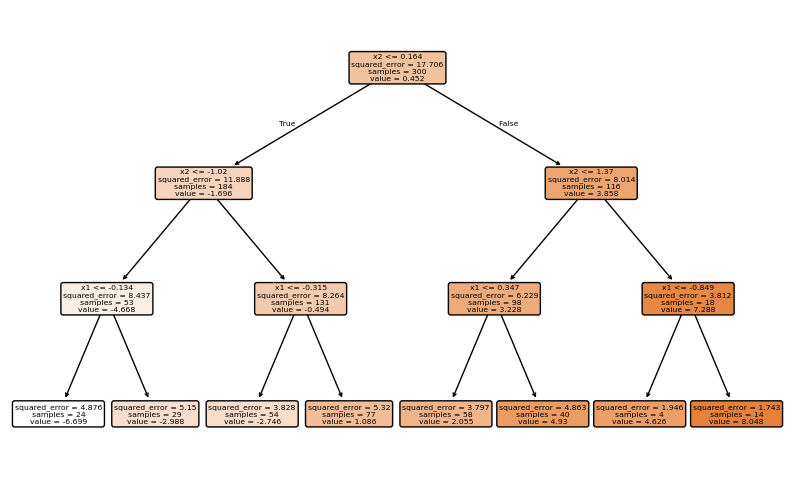

In [36]:
plt.figure(figsize=(10,6))
plot_tree(tree, feature_names=["x1", "x2"], filled=True, rounded=True)
plt.show()

Comparison with data generation
The linear regression model should recover coefficients close to 1 for the intercept, 2 for 
x
1
x 
1
 , and 3 for 
x
2
x 
2
 , meaning it almost exactly recovers the way 
y
1
y 
1
  was generated. The regression tree, in contrast, produces a piecewise-constant approximation without explicit coefficients equal to 2 and 3.

Comparison of the tree diagram with the true model
In the tree, there will be successive splits on threshold values of 
x
1
x 
1
  and 
x
2
x 
2
 , creating “quadrants” of the feature space in which a constant prediction is made. This corresponds to a stepwise function rather than a single smooth plane.

Quality of fit
On the training data, the tree can achieve an MSE similar to or even smaller than that of linear regression if it is not strongly regularized, because it can overfit. However, it does a poorer job of representing the truly linear, smooth relationship, and on test data it typically performs worse than the linear model.

Conclusion
When the true function 
f
(
X
)
f(X) is linear and additive, linear regression is:

more parameter-efficient (it uses few parameters),

providing better or at least comparable predictions,

and yielding easily interpretable coefficients.

In this situation, CART/regression trees are usually inferior in terms of overall predictive accuracy and in terms of how clearly they represent the underlying linear structure.

2.

In [37]:
x11 = (x1 > 0).astype(int)
x22 = (x2 > 0).astype(int)

y = 1 + 2 * x11 + 3 * x22 + error

X_bin = np.column_stack([x11, x22])

In [38]:
lin_reg_bin = LinearRegression()
lin_reg_bin.fit(X_bin, y)

print("Linear regression (binary) coefficients:")
print("intercept:", lin_reg_bin.intercept_)
print("coef:", lin_reg_bin.coef_)

Linear regression (binary) coefficients:
intercept: 0.7831268779848584
coef: [1.83387301 3.24599724]


In [39]:
y_pred_lin_bin = lin_reg_bin.predict(X_bin)
mse_lin_bin = mean_squared_error(y, y_pred_lin_bin)
print("MSE linear (binary):", mse_lin_bin)

MSE linear (binary): 3.6646295611871618


In [40]:
tree_bin = DecisionTreeRegressor(random_state=0, max_depth=3)
tree_bin.fit(X_bin, y)

y_pred_tree_bin = tree_bin.predict(X_bin)
mse_tree_bin = mean_squared_error(y, y_pred_tree_bin)
print("MSE tree (binary):", mse_tree_bin)

MSE tree (binary): 3.6633299203789496


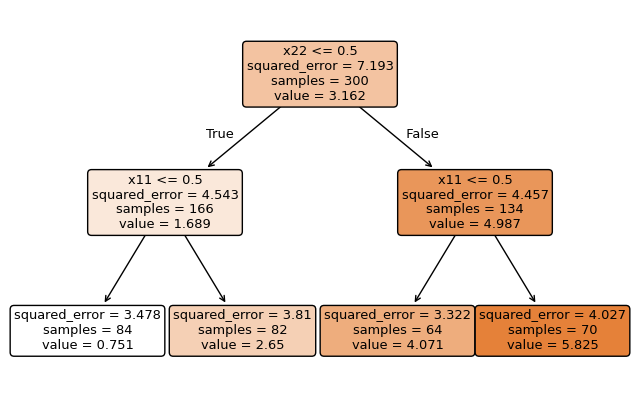

In [41]:
plt.figure(figsize=(8,5))
plot_tree(tree_bin, feature_names=["x11", "x22"], filled=True, rounded=True)
plt.show()

For a stepwise additive relationship, both linear regression with binary predictors and a regression tree are well suited in terms of functional form. Linear regression provides a compact formula with coefficients close to (1, 2, 3), while the tree gives an explicit “decision table”: branches that clearly show the conditional means for different combinations of the binary factors. In terms of MSE, their performance can be similar; the tree can be especially convenient for interpreting thresholds and interactions, whereas linear regression is better for a parametric interpretation of the effects.

3.1. How well predictions match observations
CART (regression trees) often achieve better predictive performance when the relationship between 
Y
Y and 
X
X is nonlinear and complex, with strong interactions and threshold effects. They are also advantageous when there are sharp discontinuities or regions with different regimes, such as piecewise constant or piecewise smooth behavior. In addition, trees are useful when it is important to automatically discover complex interactions between predictors rather than specifying them manually. In contrast, when the relationship is smooth and (quasi-)linear with weak interactions, linear regression usually produces more stable and accurate predictions.

3.2. How the model represents the predictor–response relationship
From the point of view of interpretation and structure, CART is preferable when there is a need to understand a hierarchy of conditions of the form “If 
X
1
>
a
X 
1
 >a and 
X
2
<
b
X 
2
 <b, then …”. Trees are also helpful when the model must be presented as an intuitive decision rule for people without a strong statistical background, and when working with mixed types of predictors (numeric and categorical) without heavy preprocessing. Linear regression is preferable when an explicit formula of the form 
Y
=
β
0
+
β
1
X
1
+
…
Y=β 
0
 +β 
1
 X 
1
 +… is needed, when effect estimates and hypothesis testing (p-values, confidence intervals) are important, and when there is reason to believe that the true relationship is close to linear or can be approximated by a linear model after reasonable transformations.

# CART and Gini Index


### Overview and Dataset
In this notebook, we will use a **Decision Tree** classifier to predict the **Tax_Regime** (Exempt, Flat, or Progressive) for various entities (companies/individuals), given their **Country**, **Industry**, **Annual_Income**, and **Number_of_Employees**. 

We will also explore how **Gini impurity** guides the tree's splitting decisions.


## Part 1: Gini Impurity and Manual Split Calculations

### Task - 1 Compute the Root Gini Impurity
    Understand the dataset and find interesting patterns :
        - Calculate the overall Gini of the target variable (Tax_Regime) for the entire dataset
        - Show your formula and numerical steps for first 10-15 rows

In [42]:
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Load YOUR dataset
df = pd.read_csv('tax_data.csv')
print("Dataset shape:", df.shape)
print("\nFirst 15 rows:")
print(df.head(15))
print("\nDataset info:")
print(df.info())
print("\nTarget distribution:")
print(df['Tax_Regime'].value_counts())

def gini_impurity(y):
    """Calculate Gini impurity: 1 - Σ(p_i²)"""
    if len(y) == 0:
        return 0
    counts = Counter(y)
    probs = [count/len(y) for count in counts.values()]
    return 1 - sum(p**2 for p in probs)

# Root Gini for entire dataset
root_gini = gini_impurity(df['Tax_Regime'])
print(f"\n=== ROOT GINI IMPURITY ===")
print(f"Root Gini: {root_gini:.4f}")

# Manual calculation for first 15 rows
subset_15 = df['Tax_Regime'].iloc[:15]
counts_15 = Counter(subset_15)
print(f"\nFirst 15 rows: {counts_15}")
probs_15 = {k: v/15 for k, v in counts_15.items()}
gini_15 = 1 - sum(p**2 for p in probs_15.values())
print(f"Gini first 15 rows: {gini_15:.4f}")
print(f"Proportions: {probs_15}")

Dataset shape: (107, 5)

First 15 rows:
    Country       Industry  Annual_Income  Employees   Tax_Regime
0       USA           Tech         120000         10  Progressive
1       USA         Retail          30000          2         Flat
2       USA        Finance          45000          3         Flat
3    Canada           Tech          80000          5  Progressive
4    Canada  Manufacturing          35000         15         Flat
5    Canada         Retail          20000          1       Exempt
6        UK        Finance         110000         12  Progressive
7        UK     Consulting          60000          3         Flat
8        UK         Retail          25000          2       Exempt
9   Germany           Tech          90000          8  Progressive
10  Germany  Manufacturing          40000         10         Flat
11  Germany         Retail          23000          2       Exempt
12   France     Consulting          70000          4         Flat
13   France         Retail          

### Task 2 – Split by One Feature
    Understand the dataset and find interesting patterns :
        - Choose one feature (e.g., Annual_Income, Employees, or a categorical column) to perform a manual split
            - If numeric (e.g., Annual_Income): pick a threshold (e.g., s < 60000 vs. s >= 60000)
            - If categorical (e.g., Country): pick some subset of countries vs. the others 
        - Separate the dataset into two subsets and compute the Gini impurity for each subset

In [43]:
# Choose split (adjust threshold based on your data)
threshold = df['Annual_Income'].median()  # or try 60000
print(f"Using threshold: {threshold:.0f}")

# Split dataset
left = df[df['Annual_Income'] < threshold]['Tax_Regime']
right = df[df['Annual_Income'] >= threshold]['Tax_Regime']

print(f"\n=== SPLIT RESULTS ===")
print(f"Left (Income < {threshold:.0f}): n={len(left)}")
print(f"  Counts: {Counter(left)}")
print(f"  Gini Left: {gini_impurity(left):.4f}")

print(f"\nRight (Income >= {threshold:.0f}): n={len(right)}")
print(f"  Counts: {Counter(right)}")
print(f"  Gini Right: {gini_impurity(right):.4f}")


Using threshold: 50000

=== SPLIT RESULTS ===
Left (Income < 50000): n=52
  Counts: Counter({'Exempt': 32, 'Flat': 20})
  Gini Left: 0.4734

Right (Income >= 50000): n=55
  Counts: Counter({'Progressive': 31, 'Flat': 24})
  Gini Right: 0.4919


### Task 3 - Weighted Average Gini After Split


$$

G(t) = p_l \cdot G(t_l) + p_r \cdot G(t_r)

$$
where :
- $  G(t)  $ : Represents the **Gini impurity of the split** at a node $  t  $ .
- $  p_l  $ : Proportion of samples in the **left child** ($  t_l  $ ).
- $  G(t_l)  $ : Gini impurity of the left child.
- $  p_r  $ : Proportion of samples in the **right child** ($  t_r  $ ).
- $  G(t_r)  $ : Gini impurity of the right child.



Compare this to the root Gini impurity and discuss if the reduction is significant

In [44]:
# Weighted Gini calculation
p_left = len(left) / len(df)
p_right = len(right) / len(df)
weighted_gini = p_left * gini_impurity(left) + p_right * gini_impurity(right)

print(f"\n=== WEIGHTED GINI ===")
print(f"p_left = {p_left:.3f}, p_right = {p_right:.3f}")
print(f"Weighted Gini: {weighted_gini:.4f}")
print(f"Root Gini: {root_gini:.4f}")
print(f"Gini reduction: {root_gini - weighted_gini:.4f}")

reduction_pct = ((root_gini - weighted_gini) / root_gini) * 100
print(f"Reduction %: {reduction_pct:.1f}%")
print(f"Significant? {'YES' if reduction_pct > 5 else 'NO'}")


=== WEIGHTED GINI ===
p_left = 0.486, p_right = 0.514
Weighted Gini: 0.4829
Root Gini: 0.6575
Gini reduction: 0.1746
Reduction %: 26.6%
Significant? YES


## Part 2: Building and Evaluating a Decision Tree

### Task 1 - Data Preparation
Prepare the data as usual :

    - Do some data analysis (they should be insighful for the problem)
    - For categorical features (Country, Industry), convert them to dummy variables
    - Split off the target
    - Create a 70/30 train-test split

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# EDA
print("\n=== EDA INSIGHTS ===")
print("Income by Tax Regime:")
print(df.groupby('Tax_Regime')['Annual_Income'].agg(['mean', 'median', 'std']).round(0))

print("\nEmployees by Tax Regime:")
print(df.groupby('Tax_Regime')['Employees'].agg(['mean', 'median', 'std']).round(0))

# Identify categorical/numeric columns
categorical_features = df.select_dtypes(include=['object', 'category']).columns.drop('Tax_Regime', errors='ignore').tolist()
numeric_features = df.select_dtypes(include=[np.number]).columns.drop('Tax_Regime', errors='ignore').tolist()

print(f"\nCategorical: {categorical_features}")
print(f"Numeric: {numeric_features}")

# Prepare X, y
X = df.drop('Tax_Regime', axis=1)
y = df['Tax_Regime']

# 70/30 stratified split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, 
                                                    random_state=42, stratify=y)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")



=== EDA INSIGHTS ===
Income by Tax Regime:
                 mean   median      std
Tax_Regime                             
Exempt        23688.0  24500.0   5866.0
Flat          53727.0  50000.0  15891.0
Progressive  103000.0  99000.0  17363.0

Employees by Tax Regime:
             mean  median  std
Tax_Regime                    
Exempt        2.0     2.0  1.0
Flat          6.0     6.0  3.0
Progressive  12.0    12.0  4.0

Categorical: ['Country', 'Industry']
Numeric: ['Annual_Income', 'Employees']
Train: 74, Test: 33


### Task 2 - Decision Tree Classifier with Gini
    - Initialize and fit
    - Tune hyperparameters like max_depth, min_samples_leaf, etc

In [46]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ])

# Decision Tree pipeline
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        criterion='gini', 
        random_state=42,
        max_depth=4,
        min_samples_leaf=5,
        min_samples_split=10
    ))
])

# Fit
dt_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Country', 'Industry']),
                                                 ('num', 'passthrough',
                                                  ['Annual_Income',
                                                   'Employees'])])),
                ('classifier',
                 DecisionTreeClassifier(max_depth=4, min_samples_leaf=5,
                                        min_samples_split=10,
                                        random_state=42))])

### Task 3 - Predictions and Evaluation
    - Predict on the test set
    - Calculate and analyse different classification metrics


=== TRAIN PERFORMANCE ===
              precision    recall  f1-score   support

      Exempt       0.92      1.00      0.96        22
        Flat       0.93      0.93      0.93        30
 Progressive       1.00      0.91      0.95        22

    accuracy                           0.95        74
   macro avg       0.95      0.95      0.95        74
weighted avg       0.95      0.95      0.95        74


=== TEST PERFORMANCE ===
              precision    recall  f1-score   support

      Exempt       0.77      1.00      0.87        10
        Flat       0.85      0.79      0.81        14
 Progressive       1.00      0.78      0.88         9

    accuracy                           0.85        33
   macro avg       0.87      0.85      0.85        33
weighted avg       0.86      0.85      0.85        33



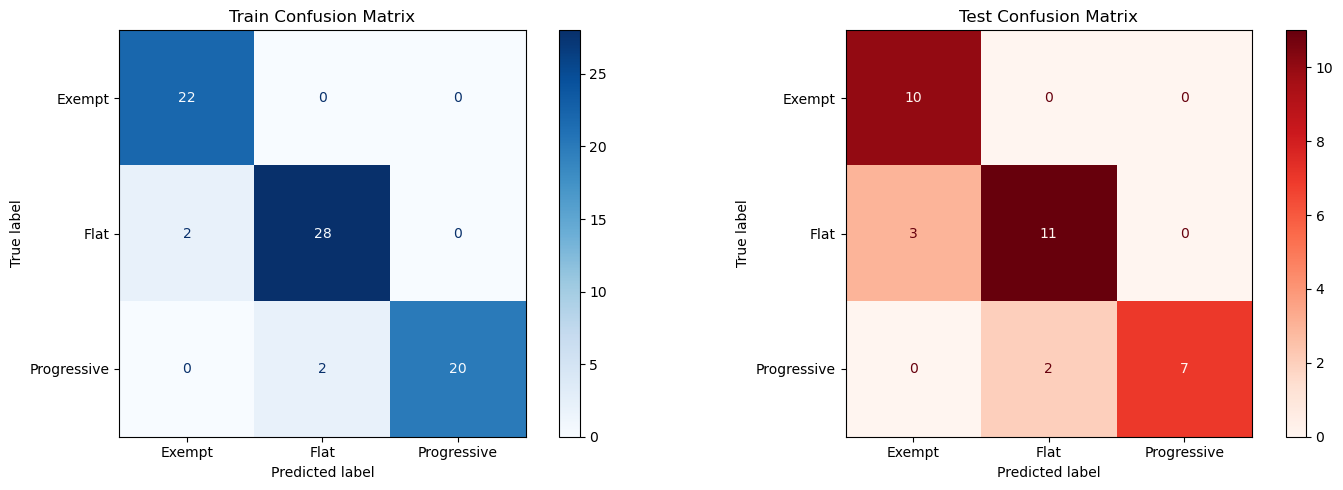

In [47]:
# Predictions
y_pred_train = dt_pipeline.predict(X_train)
y_pred_test = dt_pipeline.predict(X_test)

print("\n=== TRAIN PERFORMANCE ===")
print(classification_report(y_train, y_pred_train))

print("\n=== TEST PERFORMANCE ===")
print(classification_report(y_test, y_pred_test))

# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train, ax=axes[0], cmap='Blues')
axes[0].set_title('Train Confusion Matrix')
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, ax=axes[1], cmap='Reds')
axes[1].set_title('Test Confusion Matrix')
plt.tight_layout()
plt.show()


### Task 4 - Tree Structure
    - Plot and check out how is the tree splitting
    - Compare the top splits with your manual Gini analysis from Part 1
    - Re train with different max_depth values and compare
    - Discuss what are the pro and cons of growing a deep Tree
    - Remember what is the variance of an estimator. Discuss why the variance of a decision tree might be large. Find a way to vizualize it.

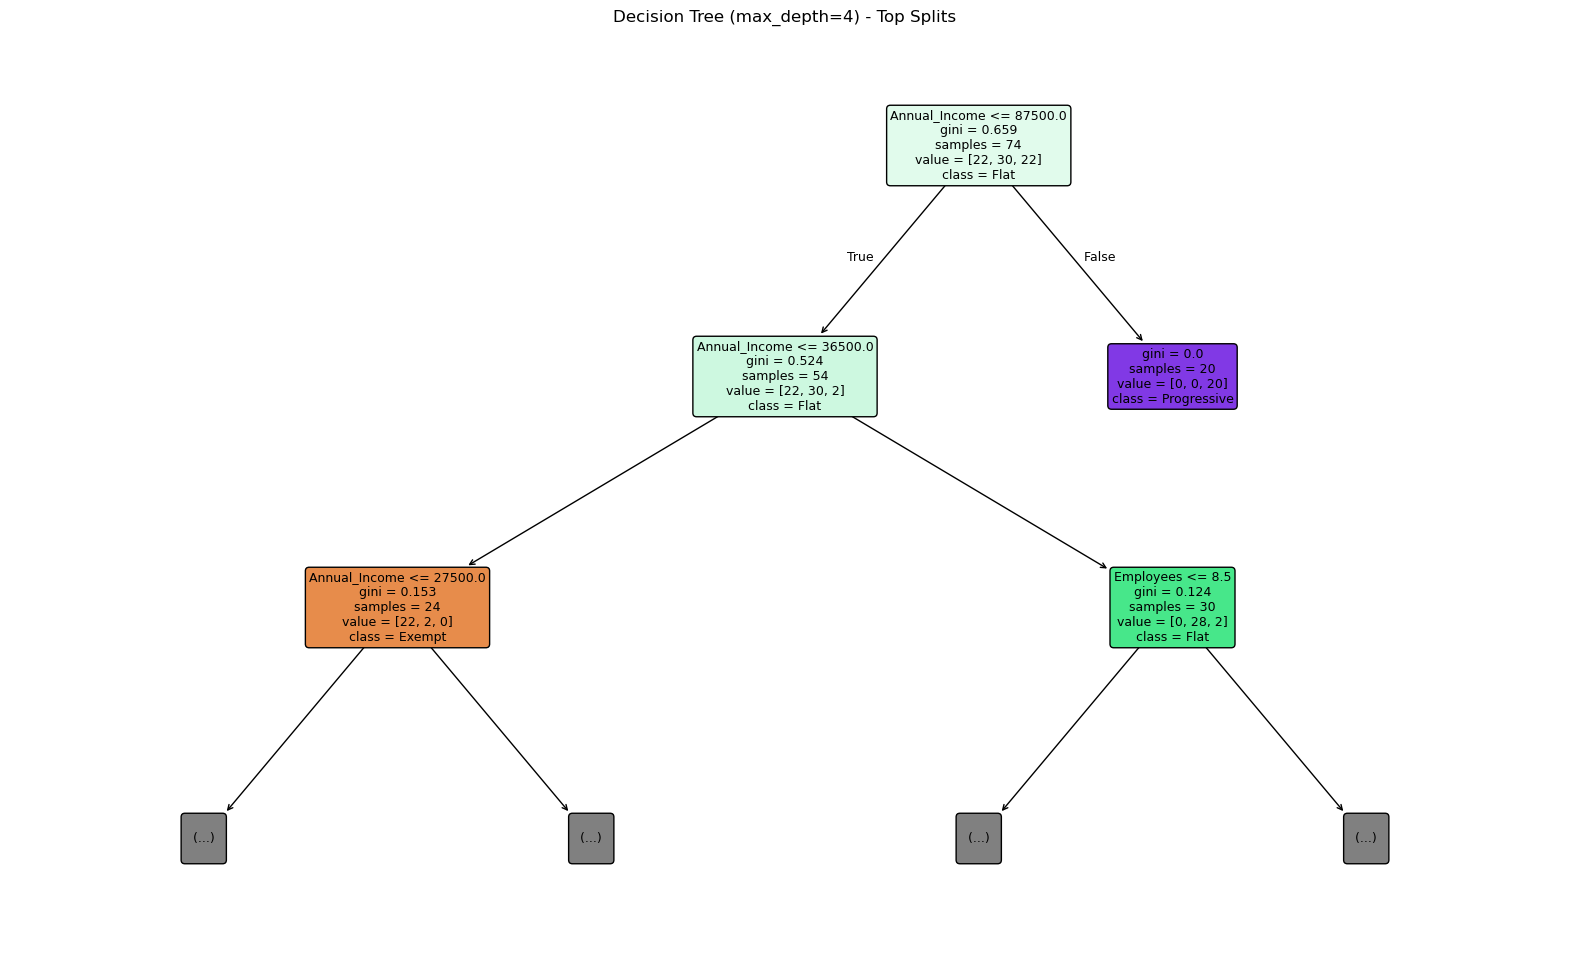


=== TOP TREE SPLITS vs MANUAL ===
Tree feature importances:
           feature  importance
18   Annual_Income    0.975182
19       Employees    0.024818
0   Country_Brazil    0.000000
1   Country_Canada    0.000000
3   Country_France    0.000000


In [48]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Extract feature names and tree
tree = dt_pipeline.named_steps['classifier']
preproc = dt_pipeline.named_steps['preprocessor']
cat_features = preproc.named_transformers_['cat'].get_feature_names_out(categorical_features)
feature_names = np.concatenate([cat_features, numeric_features])

plt.figure(figsize=(20, 12))
plot_tree(tree, 
          feature_names=feature_names, 
          class_names=sorted(y.unique()), 
          filled=True, 
          rounded=True, 
          fontsize=9,
          max_depth=2)  # Show top levels
plt.title("Decision Tree (max_depth=4) - Top Splits")
plt.show()

# Compare with manual split
print("\n=== TOP TREE SPLITS vs MANUAL ===")
print("Tree feature importances:")
importances = pd.DataFrame({
    'feature': feature_names,
    'importance': tree.feature_importances_
}).sort_values('importance', ascending=False)
print(importances.head(5))



=== DEPTH ANALYSIS ===
   max_depth  train_acc  test_acc    gap
0        2.0      0.946     0.848  0.097
1        4.0      0.946     0.848  0.097
2        6.0      0.946     0.848  0.097
3        NaN      0.946     0.848  0.097


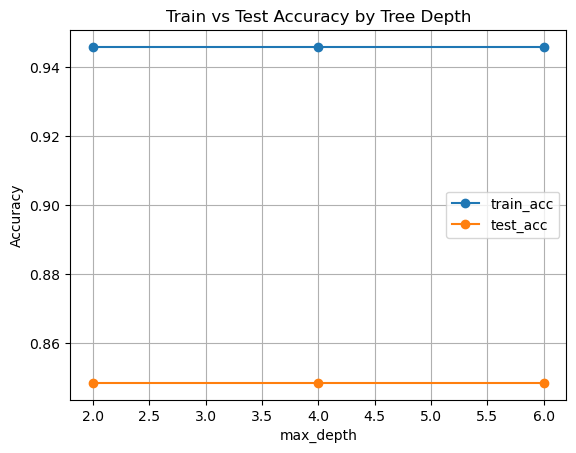

In [49]:
depths = [2, 4, 6, None]
results = []

for depth in depths:
    dt_temp = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(criterion='gini', max_depth=depth, 
                                            random_state=42, min_samples_leaf=5))
    ])
    dt_temp.fit(X_train, y_train)
    
    train_acc = (dt_temp.predict(X_train) == y_train).mean()
    test_acc = (dt_temp.predict(X_test) == y_test).mean()
    
    results.append({
        'max_depth': depth,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'gap': train_acc - test_acc
    })

results_df = pd.DataFrame(results)
print("\n=== DEPTH ANALYSIS ===")
print(results_df.round(3))

# Plot
results_df.plot(x='max_depth', y=['train_acc', 'test_acc'], marker='o')
plt.title('Train vs Test Accuracy by Tree Depth')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()



=== TREE VARIANCE ===
Deep tree test accuracies across 10 seeds: [np.float64(0.9090909090909091), np.float64(0.8787878787878788), np.float64(0.8484848484848485), np.float64(0.9090909090909091), np.float64(0.9393939393939394), np.float64(0.9696969696969697), np.float64(0.9696969696969697), np.float64(0.8484848484848485), np.float64(0.9393939393939394), np.float64(0.9393939393939394)]
Mean: 0.915, Std: 0.042


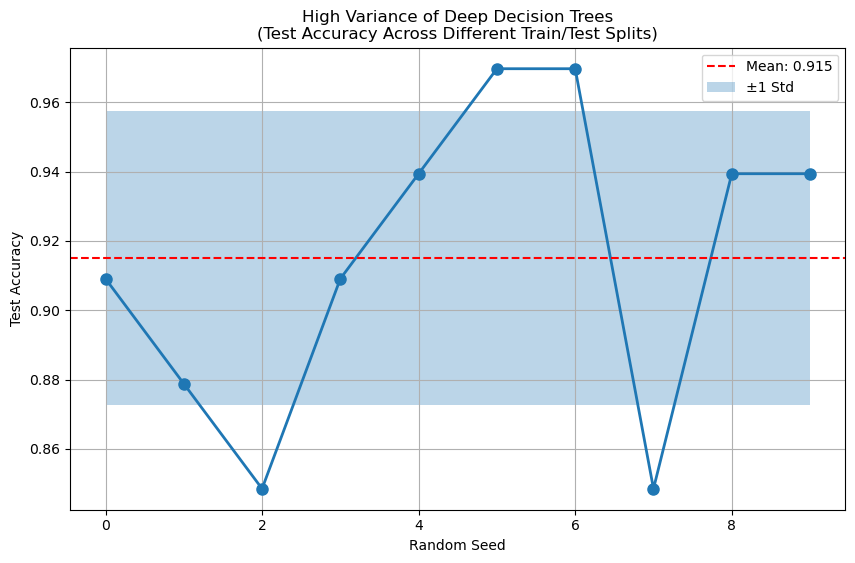

In [50]:
# Show high variance of deep trees
accuracies = []
seeds = range(10)

for seed in seeds:
    X_t, X_te, y_t, y_te = train_test_split(X, y, test_size=0.3, random_state=seed, stratify=y)
    deep_tree = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(max_depth=None, random_state=seed))
    ])
    deep_tree.fit(X_t, y_t)
    acc = (deep_tree.predict(X_te) == y_te).mean()
    accuracies.append(acc)

print(f"\n=== TREE VARIANCE ===")
print(f"Deep tree test accuracies across 10 seeds: {accuracies}")
print(f"Mean: {np.mean(accuracies):.3f}, Std: {np.std(accuracies):.3f}")

plt.figure(figsize=(10, 6))
plt.plot(seeds, accuracies, 'o-', linewidth=2, markersize=8)
plt.axhline(np.mean(accuracies), color='red', linestyle='--', label=f'Mean: {np.mean(accuracies):.3f}')
plt.fill_between(seeds, 
                np.mean(accuracies) - np.std(accuracies),
                np.mean(accuracies) + np.std(accuracies), alpha=0.3, label='±1 Std')
plt.title('High Variance of Deep Decision Trees\n(Test Accuracy Across Different Train/Test Splits)')
plt.xlabel('Random Seed')
plt.ylabel('Test Accuracy')
plt.legend()
plt.grid(True)
plt.show()
